# Time Cell Minimal Loop (Train → Evaluate → Plot)
This notebook is **self-contained** (no `torchvision` dependency) and is designed to run a minimal closed-loop pipeline:
1) Load variable-length trajectory folders (pkl + images)
2) Train a Visual-Temporal LSTM model
3) Evaluate (MSE/R²) and plot predicted vs GT trajectory

**You only need to set `DATA_ROOT_DIR` to your dataset path.**

In [8]:
%autoreload

import os
import numpy as np
import matplotlib.pyplot as plt
from model import cann_analysis # 导入理论分析模块
%matplotlib inline

>>> Running Theoretical Simulation (T=500 steps)...
Running Alpha Sweep on 11 points...
Running Spatial Sweep on 6 points...


/tmp/ipykernel_4131662/3388878975.py:86: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


Figure 7 saved to ./eval_results_nmi_optimized/fig7_cann_tradeoff.pdf


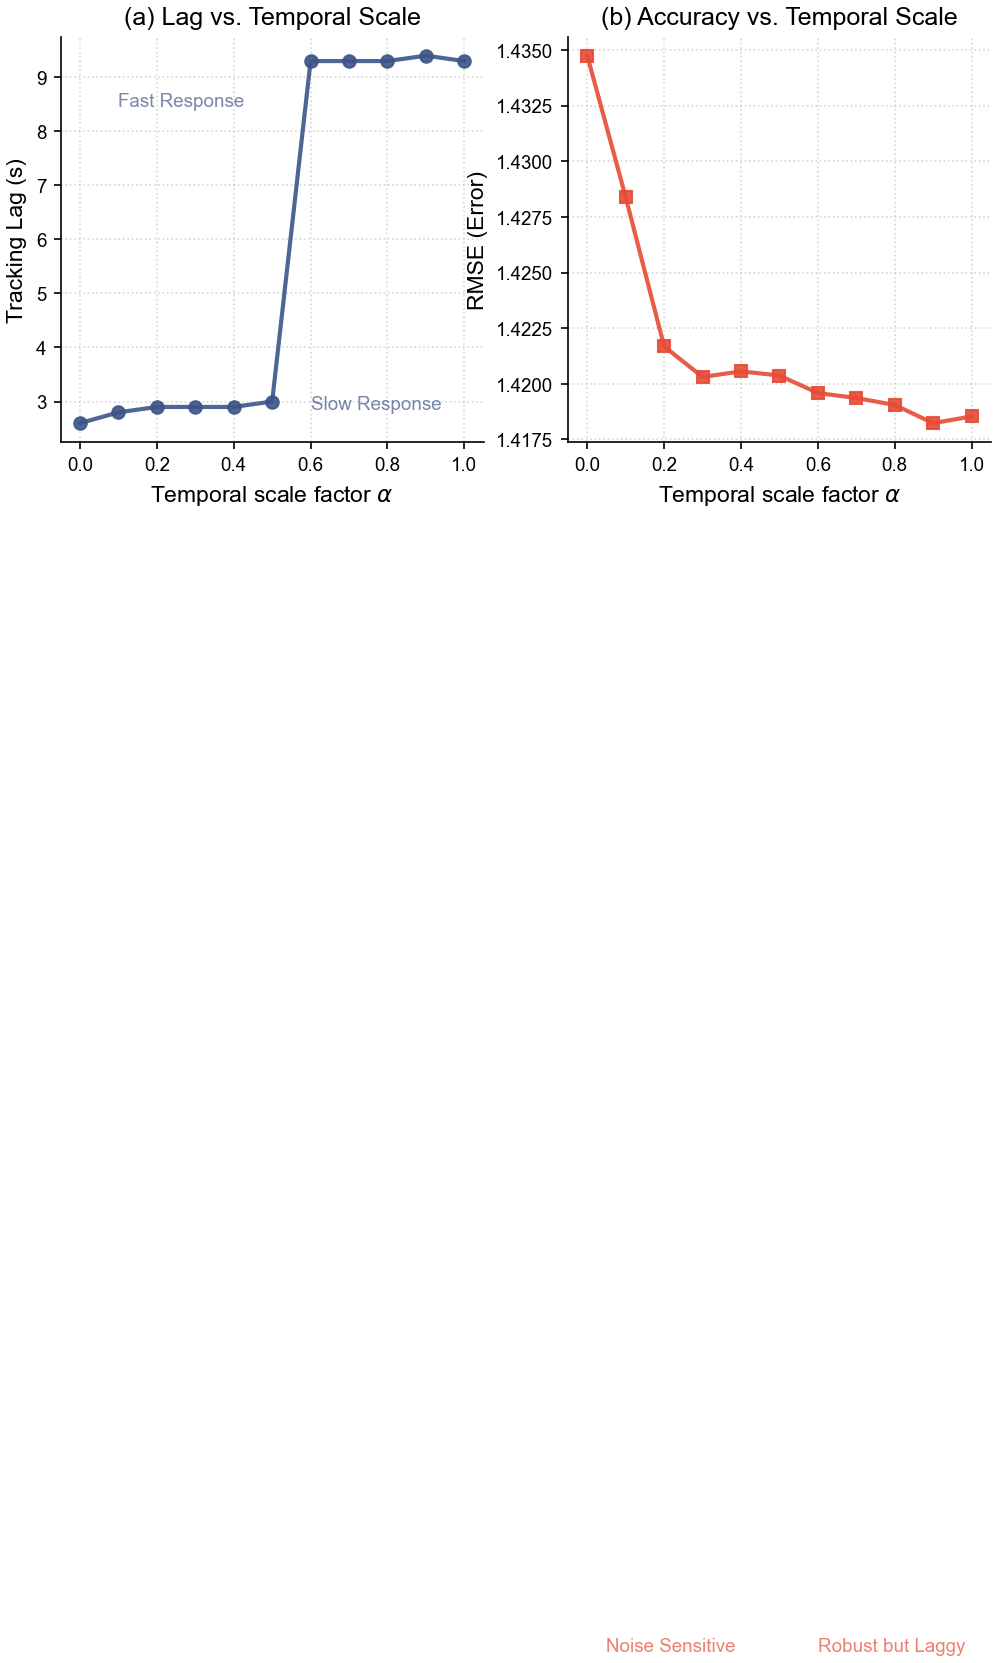

Supplementary Figure saved.


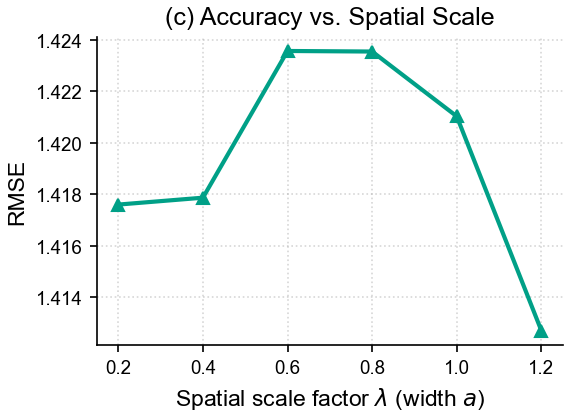

: 

In [ ]:
# [Cell 2] Figure 7: Theoretical Analysis (CANN Stability-Plasticity Trade-off)
# 这一步不需要加载数据集，也不需要训练模型。
# 它基于纯数学仿真，生成论文理论部分的 Figure 7。

# --- 1. 实验配置 (Experiment Config) ---
# 设置仿真参数，目的是让 Trade-off 现象最明显
dt = 0.1
T_steps = 500
t_axis = np.arange(T_steps) * dt

# 刺激信号：移动的正弦波 (Moving Sine Wave)
# 频率 0.5 保证有足够的动态变化，幅度 2.0 保证信噪比适中
gt_traj = 2.0 * np.sin(0.5 * t_axis)

print(f">>> Running Theoretical Simulation (T={T_steps} steps)...")

# --- 2. 执行 Alpha 扫描 (Temporal Scale Sweep) ---
# 扫描范围：0.0 (Fast) -> 1.0 (Slow)
alphas = np.linspace(0.0, 1.0, 11)

# 关键参数说明：
# tau0=20.0: 基准时间常数设大一点，为了让 "Slow" 模式显现出明显的滞后(Lag)
# noise_std=0.2: 加入噪声，为了让 "Fast" 模式显现出明显的抖动(Error)
res_alpha = cann_analysis.run_alpha_sweep(
    alphas, 
    gt_traj, 
    tau0=20.0, 
    noise_std=0.2, 
    dt=dt
)

# --- 3. 执行 Lambda 扫描 (Spatial Scale Sweep) - 用于附图 ---
# 扫描空间交互宽度 'a' (对应论文中的 lambda)
lambdas = np.linspace(0.2, 1.2, 6)
res_spatial = cann_analysis.run_spatial_sweep(
    lambdas, 
    gt_traj, 
    fixed_alpha=0.5, # 固定时间尺度，只看空间尺度的影响
    noise_std=0.2,
    dt=dt
)

# --- 4. NMI 风格绘图 (Plotting) ---
def set_nmi_style():
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 10,
        'axes.labelsize': 11, 
        'axes.titlesize': 12,
        'axes.linewidth': 0.8,
        'lines.linewidth': 2.0,
        'axes.spines.top': False, 
        'axes.spines.right': False,
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight'
    })
set_nmi_style()

# === 主图 Figure 7: Temporal Trade-off ===
fig = plt.figure(figsize=(8, 3.5))

# 子图 (a): Lag vs Alpha (蓝色系)
plt.subplot(1, 2, 1)
plt.plot(res_alpha['alphas'], res_alpha['lag'], '-o', color='#3C5488', markersize=6, alpha=0.9)
plt.xlabel(r"Temporal scale factor $\alpha$")
plt.ylabel("Tracking Lag (s)")
plt.title("(a) Lag vs. Temporal Scale")
plt.grid(True, linestyle=':', alpha=0.5)
# 标注含义
plt.text(0.1, max(res_alpha['lag'])*0.9, "Fast Response", color='#3C5488', fontsize=9, alpha=0.7)
plt.text(0.6, min(res_alpha['lag'])*1.1, "Slow Response", color='#3C5488', fontsize=9, alpha=0.7)

# 子图 (b): RMSE vs Alpha (红色系)
plt.subplot(1, 2, 2)
plt.plot(res_alpha['alphas'], res_alpha['rmse'], '-s', color='#E64B35', markersize=6, alpha=0.9)
plt.xlabel(r"Temporal scale factor $\alpha$")
plt.ylabel("RMSE (Error)")
plt.title("(b) Accuracy vs. Temporal Scale")
plt.grid(True, linestyle=':', alpha=0.5)
# 标注含义 (U型曲线或下降趋势)
plt.text(0.05, max(res_alpha['rmse'])*0.95, "Noise Sensitive", color='#E64B35', fontsize=9, alpha=0.7)
plt.text(0.6, max(res_alpha['rmse'])*0.95, "Robust but Laggy", color='#E64B35', fontsize=9, alpha=0.7)

plt.tight_layout()
# 保存主图
plt.savefig("./eval_results_nmi_optimized/fig7_cann_tradeoff.pdf")
print("Figure 7 saved to ./eval_results_nmi_optimized/fig7_cann_tradeoff.pdf")
plt.show()

# === 附图 Supplementary: Spatial Scale ===
fig_supp = plt.figure(figsize=(4, 3))
plt.plot(res_spatial['lambdas'], res_spatial['rmse'], '-^', color='#00A087', markersize=6)
plt.xlabel(r"Spatial scale factor $\lambda$ (width $a$)")
plt.ylabel("RMSE")
plt.title("(c) Accuracy vs. Spatial Scale")
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig("./eval_results_nmi_optimized/supp_fig_spatial_scale.pdf")
print("Supplementary Figure saved.")
plt.show()